<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 2.2</h1>

The aim of this exercise is to simulate a three-dimensional random walk in two different cases: a discrete random walk on a cubic lattice and a continuous random walk, in which the direction of each step is chosen isotropically. For both cases, the evolution of the walker will be studied as a function of the number of steps. This allows us to verify numerically the characteristic diffusive behaviour of random walks and to investigate the agreement between the discrete and continuous descriptions.


### Stochastic and Markov processes

A stochastic process is a family of random variables $({X_t})_{t\in I}$, where the index set $I$ represents the parameter describing the evolution of the process, typically time. Depending on whether $I$ is discrete or continuous, one distinguishes between discrete-time and continuous-time stochastic processes.

A stochastic process is characterized by its joint probability distributions. The joint probability density at $n$ different times can be written as

$$
p_n(x_1,t_1;\ldots;x_n,t_n),
$$

which gives the probability density of finding the process at the values $x_1,\ldots,x_n$ at the corresponding times $t_1,\ldots,t_n$. These probability distributions must satisfy the usual properties of positivity and normalization, together with the consistency conditions obtained by integrating over one or more variables.

From the joint probability distribution, statistical quantities characterizing the process can be defined. In particular, the first moment, also called the mean of the process, is

$$
\langle X(t_1)\ldots X(t_n)\rangle = \int x_1\ldots x_n p_n(x_1,t_1;\ldots;x_n,t_n)dx_1\ldots dx_n.
$$

More generally, correlations between the values of the process at two different times can be described through the covariance matrix

$$
C_{ij}=\langle X(t_i)X(t_j)\rangle -\langle X(t_i)\rangle\langle X(t_j)\rangle.
$$

A stochastic process is said to be a Markov process if its future evolution depends only on its present state and not on the previous history of the process. For ordered times $t_1<t_2<\ldots<t_n<t_{n+1}$, this condition can be expressed in terms of conditional probabilities as

$$
p_{1|n}(x_{n+1},t_{n+1}\mid x_1,t_1;\ldots;x_n,t_n)=p_{1|1}(x_{n+1},t_{n+1}\mid x_n,t_n).
$$

Thus, once the state of the process at time $t_n$ is known, the knowledge of all previous states does not provide any additional information about the state at time $t_{n+1}$. For this reason, Markov processes are said to be memoryless.

A Markov process is therefore completely characterized by its initial probability distribution $p_1(x_1,t_1)$ and its transition probability

$$
p_{1|1}(x_{n+1},t_{n+1}\mid x_n,t_n),
$$

which describes the probability of transitioning from a state $x_n$ at time $t_n$ to a state $x_{n+1}$ at time $t_{n+1}$.

The transition probabilities of a Markov process satisfy the Chapman–Kolmogorov equation. For three ordered times $t_1<t_2<t_3$, it reads

$$
p_{1|1}(x_3,t_3\mid x_1,t_1)=\int dx_2
p_{1|1}(x_3,t_3\mid x_2,t_2)
p_{1|1}(x_2,t_2\mid x_1,t_1).
$$

This equation expresses the fact that a transition between two states can be decomposed into a sequence of intermediate transitions. The final state can be reached through any possible intermediate state $x_2$, and the corresponding probabilities are summed over all such possibilities.

### Random walk

A random walk is the mathematical formalization of a trajectory consisting of a sequence of random steps. It can be described as a Markov process, since the probability of performing the next step depends only on the current position of the walker and not on its previous history.

Consider first a one-dimensional lattice with spacing $a$ along the $x$-axis, and associate a time interval $\tau$ with each step. The probability of finding the walker at the position $na$ after $s$ steps can be obtained from the transition probability,

$$
p_1(na,(s+1)\tau)
=\sum_{m=-\infty}^{+\infty}
p_{1|1}(na,(s+1)\tau\mid ma,s\tau)
p_1(ma,s\tau).
$$

For a symmetric random walk, the walker has equal probability of moving one lattice spacing to the right or to the left at each step. Therefore, the transition probability is non-zero only for neighboring lattice sites, with

$$
p_{1|1}(na,(s+1)\tau\mid ma,s\tau)
=\frac{1}{2}\delta_{n,m+1}
+
\frac{1}{2}\delta_{n,m-1}.
$$

The evolution equation for the probability distribution consequently becomes

$$
p_1(na,(s+1)\tau)
=\frac{1}{2}p_1((n-1)a,s\tau)
+
\frac{1}{2}p_1((n+1)a,s\tau).
$$

Taking the continuum limit, in which the lattice spacing $a$ and the time interval $\tau$ become infinitesimal while their ratio is kept such that the diffusion coefficient remains finite, this discrete equation leads to the diffusion equation

$$
\frac{\partial p_1(x,t)}{\partial t}
=D\frac{\partial^2p_1(x,t)}{\partial x^2},
$$

where the diffusion coefficient is

$$
D=\frac{a^2}{2\tau}.
$$

This result shows that, on sufficiently large spatial and temporal scales, a symmetric random walk exhibits the characteristic diffusive behaviour described by the diffusion equation.

The solution of the diffusion equation with the initial condition $p_1(x,0)=\delta(x)$ describes the probability distribution of a walker initially located at the origin. The mean position remains equal to zero,

$$
\langle x(t)\rangle=0,
$$

while the mean square displacement grows linearly with time,

$$
\langle x^2(t)\rangle=2Dt.
$$

In $d$ spatial dimensions, the squared distance from the origin is

$$
r^2=x_1^2+x_2^2+\ldots+x_d^2,
$$

and therefore the mean square displacement is

$$
\langle r^2(t)\rangle=2dDt.
$$

For a random walk on a cubic lattice, each step has length $a$ and the walker can move along one of the $2d$ nearest-neighbour directions. Since only one coordinate changes at each step, the diffusion coefficient is

$$
D=\frac{a^2}{2d\tau}.
$$

Identifying the time with the number of steps through $t=N\tau,$ the mean square displacement becomes

$$
\langle r^2(N)\rangle=  2d\frac{a^2}{2d\tau}N\tau.
$$

Thus, independently of the dimensionality, the root mean square distance from the origin is expected to grow as

$$
\sqrt{\langle r^2(N)\rangle}=a\sqrt{N}.
$$

For a unit step length, $a=1$, the theoretical prediction therefore reduces to

$$
\sqrt{\langle r^2(N)\rangle}=\sqrt{N}.
$$

This square-root dependence on the number of steps provides the theoretical prediction against which the numerical results for the discrete random walk can be compared.


### Implementation of the random walk simulation

To handle the random walk simulation, the `Results` structure was extended with three additional members: `ave_rw`, `ave_rw_prog`, and `err_rw_prog`. These store, respectively, the average value obtained in each block for every step of the random walk, the corresponding progressive averages, and their statistical uncertainties.

The simulation is performed by the `run_RW` function, implemented in `Simulation.cpp`. For each block, the function generates $L$ independent random walks, each containing `n_steps` steps. The function passed through `func` generates the random-walk configurations, while `estimator` can be used to evaluate the desired quantity at each step.

The average is first calculated independently for each step of the random walk and for each block, and is stored in `ave_rw`. The progressive averages and their statistical uncertainties are then calculated by combining the results from the different blocks. The optional `transform` and `error_transform` functions allow the estimated quantity and its uncertainty to be transformed when required.

The function therefore provides the same data-blocking framework used by `run`, but extended to handle several random-walk steps simultaneously. This allows the progressive averages and statistical errors to be obtained independently for each step of the walk.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math

In [2]:
disc = np.loadtxt('disc_ave_rw_prog.txt')
disc_err = np.loadtxt('disc_err_rw_prog.txt')
cont = np.loadtxt('cont_ave_rw_prog.txt')
cont_err = np.loadtxt('cont_err_rw_prog.txt')

In [3]:
M = 10000
N = 100
x = np.arange(1, len(disc) + 1)

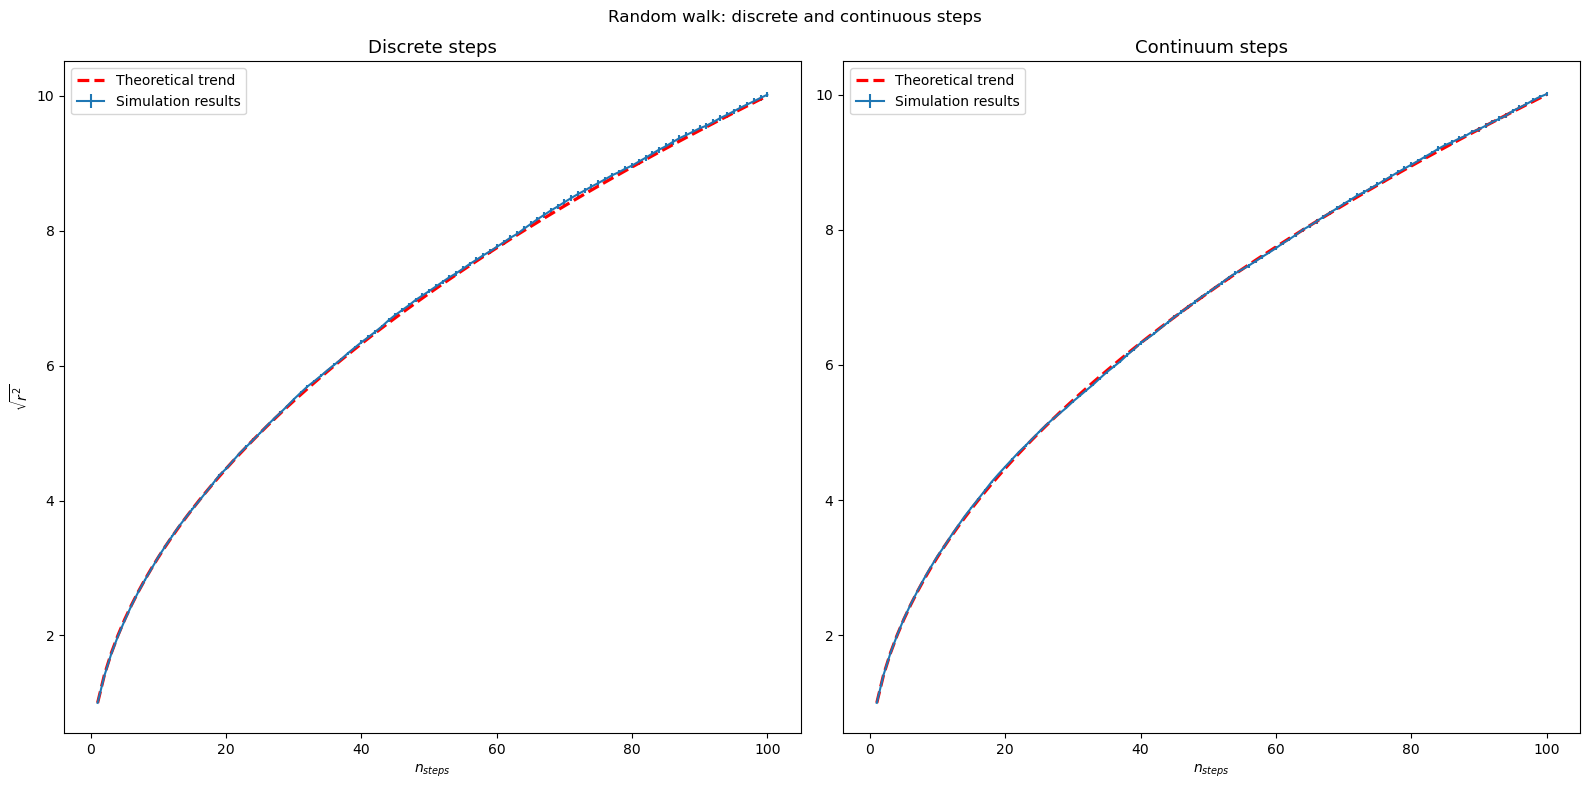

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

datasets = [disc, cont]
errorsets = [disc_err, cont_err]
titles = [
    "Discrete steps",
    "Continuum steps"
]

for ax, data, error, title in zip(axs, datasets, errorsets, titles):

    ax.errorbar(x, data, yerr=error, label='Simulation results')
    ax.plot(x, np.sqrt(x), linestyle='--', linewidth=2.3, color='red', label='Theoretical trend')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("$n_{steps}$")

    ax.legend()

axs[0].set_ylabel('$\sqrt{r^2}$')
plt.suptitle('Random walk: discrete and continuous steps')

plt.tight_layout()
plt.show()
    

**Figure 1.** Progressive averages of the root-mean-square displacement as a function of the number of steps for the discrete random walk (left) and the continuous random walk (right), obtained using data blocking with $M=10000$ throws and $N=100$ blocks. The theoretical prediction $\sqrt{N}$ for unit step length $a=1$ is also shown.


For both types of random walk, the simulation data closely overlap with the theoretical curve $\sqrt{N}$ over the whole range of steps. The agreement confirms that the root-mean-square displacement grows proportionally to the square root of the number of steps, as expected from the diffusion behaviour of a random walk.
